**Author:** Andiwam Mkpong  
**Project Type:** Finance / Risk Management / Investment Analysis  

This project uses Monte Carlo simulation to forecast potential portfolio outcomes and analyze downside risk using real market data.

In [77]:
# Install required packages
!pip -q install yfinance pandas_datareader plotly seaborn

# Imports
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
from typing import Dict, List

import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

## 1. Project Inputs

Change the tickers, portfolio weights, starting investment, simulation length, or number of simulations below. The default portfolio is a simple equity portfolio across technology, financials, and the broad market.

In [78]:
# -----------------------------
# User inputs
# -----------------------------

TICKERS = ["AAPL", "MSFT", "NVDA", "JPM", "SPY"]

WEIGHTS = {
    "AAPL": 0.20,
    "MSFT": 0.20,
    "NVDA": 0.20,
    "JPM": 0.15,
    "SPY": 0.25
}

START_DATE = "2018-01-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")

INITIAL_PORTFOLIO_VALUE = 100_000
TRADING_DAYS_PER_YEAR = 252
FORECAST_YEARS = 5
NUM_SIMULATIONS = 10_000
CONFIDENCE_LEVEL = 0.95
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)


def validate_inputs(tickers: List[str], weights: Dict[str, float]) -> np.ndarray:
    """
    Validates tickers and weights, then returns weights as an ordered numpy array.
    """
    if not tickers:
        raise ValueError("Ticker list cannot be empty.")

    missing_weights = [ticker for ticker in tickers if ticker not in weights]
    if missing_weights:
        raise ValueError(f"Missing weights for tickers: {missing_weights}")

    weight_values = np.array([weights[ticker] for ticker in tickers], dtype=float)

    if np.any(weight_values < 0):
        raise ValueError("Portfolio weights cannot be negative.")

    weight_sum = weight_values.sum()

    if not np.isclose(weight_sum, 1.0):
        print(f"Warning: weights sum to {weight_sum:.4f}. Normalizing weights to sum to 1.")
        weight_values = weight_values / weight_sum

    return weight_values


portfolio_weights = validate_inputs(TICKERS, WEIGHTS)

weights_table = pd.DataFrame({
    "Ticker": TICKERS,
    "Weight": portfolio_weights
})

display(weights_table.style.format({"Weight": "{:.2%}"}))

,Ticker,Weight
0,AAPL,20.00%
1,MSFT,20.00%
2,NVDA,20.00%
3,JPM,15.00%
4,SPY,25.00%


## 2. Fetch Market Data

This section trys to download adjusted closing prices from Yahoo Finance. It also attempts to pull the 3-month Treasury yield from FRED as a proxy for Beta (the risk-free rate). If the FRED request fails, I use a conservative fallback value.

In [79]:
def fetch_price_data(
    tickers: List[str],
    start_date: str,
    end_date: str
) -> pd.DataFrame:
    """
    Downloads adjusted close prices from Yahoo Finance and cleans missing data.
    """
    try:
        raw_data = yf.download(
            tickers,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            progress=False
        )

        if raw_data.empty:
            raise ValueError("Yahoo Finance returned no data.")

        if isinstance(raw_data.columns, pd.MultiIndex):
            if "Close" in raw_data.columns.get_level_values(0):
                prices = raw_data["Close"].copy()
            elif "Adj Close" in raw_data.columns.get_level_values(0):
                prices = raw_data["Adj Close"].copy()
            else:
                raise ValueError("Could not find Close or Adj Close columns in Yahoo Finance response.")
        else:
            price_column = "Close" if "Close" in raw_data.columns else "Adj Close"
            prices = raw_data[[price_column]].copy()
            prices.columns = tickers

        prices = prices.dropna(axis=1, how="all")
        prices = prices.ffill().dropna()

        available_tickers = list(prices.columns)
        missing_tickers = [ticker for ticker in tickers if ticker not in available_tickers]

        if missing_tickers:
            print(f"Warning: no usable data found for: {missing_tickers}")

        if prices.empty:
            raise ValueError("No valid price data after cleaning.")

        return prices

    except Exception as error:
        raise RuntimeError(f"Failed to fetch price data: {error}")


def fetch_risk_free_rate(start_date: str, end_date: str, fallback_rate: float = 0.04) -> float:
    """
    Fetches the latest 3-month Treasury yield from FRED.
    Returns annualized decimal rate.
    """
    try:
        fred_data = web.DataReader("DGS3MO", "fred", start_date, end_date)
        fred_data = fred_data.dropna()

        if fred_data.empty:
            raise ValueError("FRED returned no valid Treasury yield data.")

        latest_rate = fred_data["DGS3MO"].iloc[-1] / 100
        return float(latest_rate)

    except Exception as error:
        print(f"Warning: failed to fetch FRED risk-free rate. Using fallback rate of {fallback_rate:.2%}.")
        print(f"Reason: {error}")
        return fallback_rate


prices = fetch_price_data(TICKERS, START_DATE, END_DATE)
risk_free_rate = fetch_risk_free_rate(START_DATE, END_DATE)

available_tickers = list(prices.columns)
portfolio_weights = validate_inputs(available_tickers, {ticker: WEIGHTS[ticker] for ticker in available_tickers})

print(f"Price data range: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Available tickers: {available_tickers}")
print(f"Risk-free rate used: {risk_free_rate:.2%}")

display(prices.tail())

Price data range: 2018-01-02 to 2026-07-02
Available tickers: ['AAPL', 'JPM', 'MSFT', 'NVDA', 'SPY']
Risk-free rate used: 3.85%


Ticker,AAPL,JPM,MSFT,NVDA,SPY
Date,,,,,
2026-06-26,283.779999,329.049988,372.970001,192.529999,728.989990
2026-06-29,281.739990,329.390015,368.570007,194.970001,741.000000
2026-06-30,289.359985,327.329987,373.019989,200.089996,746.770020
2026-07-01,294.380005,334.070007,384.279999,197.580002,745.760010
2026-07-02,308.630005,334.470001,390.489990,194.830002,744.780029


## 3. Historical Price Performance

The chart below shows how each asset performed historically after normalizing all prices to a starting value of 100.

In [80]:
normalized_prices = prices / prices.iloc[0] * 100

fig = px.line(
    normalized_prices,
    title="Normalized Historical Price Performance",
    labels={"value": "Indexed Price, Start = 100", "Date": "Date", "variable": "Ticker"}
)

fig.update_layout(
    template="plotly_white",
    height=600,
    legend_title_text="Ticker"
)

fig.show()

## 4. Return and Risk Calculations

This section calculates daily returns, annualized returns, annualized volatility, Sharpe ratio, and historical drawdowns.

In [81]:
daily_returns = prices.pct_change().dropna()
portfolio_daily_returns = daily_returns.dot(portfolio_weights)

mean_daily_returns = daily_returns.mean()
cov_daily_returns = daily_returns.cov()

annualized_asset_returns = mean_daily_returns * TRADING_DAYS_PER_YEAR
annualized_asset_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

portfolio_annualized_return = portfolio_daily_returns.mean() * TRADING_DAYS_PER_YEAR
portfolio_annualized_volatility = portfolio_daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
portfolio_sharpe_ratio = (
    (portfolio_annualized_return - risk_free_rate) / portfolio_annualized_volatility
    if portfolio_annualized_volatility != 0
    else np.nan
)

asset_summary = pd.DataFrame({
    "Annualized Return": annualized_asset_returns,
    "Annualized Volatility": annualized_asset_volatility,
    "Sharpe Ratio": (annualized_asset_returns - risk_free_rate) / annualized_asset_volatility
}).sort_values("Sharpe Ratio", ascending=False)

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Portfolio Annualized Return",
        "Portfolio Annualized Volatility",
        "Portfolio Sharpe Ratio",
        "Risk-Free Rate Used"
    ],
    "Value": [
        portfolio_annualized_return,
        portfolio_annualized_volatility,
        portfolio_sharpe_ratio,
        risk_free_rate
    ]
})

display(Markdown("### Asset-Level Summary"))
display(asset_summary.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}"
}))

display(Markdown("### Portfolio Summary"))
portfolio_summary_display = portfolio_summary.copy()
portfolio_summary_display["Formatted Value"] = [
    f"{portfolio_annualized_return:.2%}",
    f"{portfolio_annualized_volatility:.2%}",
    f"{portfolio_sharpe_ratio:.2f}",
    f"{risk_free_rate:.2%}"
]
display(portfolio_summary_display[["Metric", "Formatted Value"]])

### Asset-Level Summary

,Annualized Return,Annualized Volatility,Sharpe Ratio
Ticker,,,
NVDA,56.23%,50.61%,1.04
AAPL,28.71%,30.56%,0.81
MSFT,23.04%,28.73%,0.67
SPY,15.42%,19.18%,0.60
JPM,20.18%,28.78%,0.57


### Portfolio Summary

,Metric,Formatted Value
0,Portfolio Annualized Return,28.48%
1,Portfolio Annualized Volatility,25.74%
2,Portfolio Sharpe Ratio,0.96
3,Risk-Free Rate Used,3.85%


## 5. Correlation Matrix

A correlation matrix helps show how closely the assets move together. Lower correlations can improve diversification.

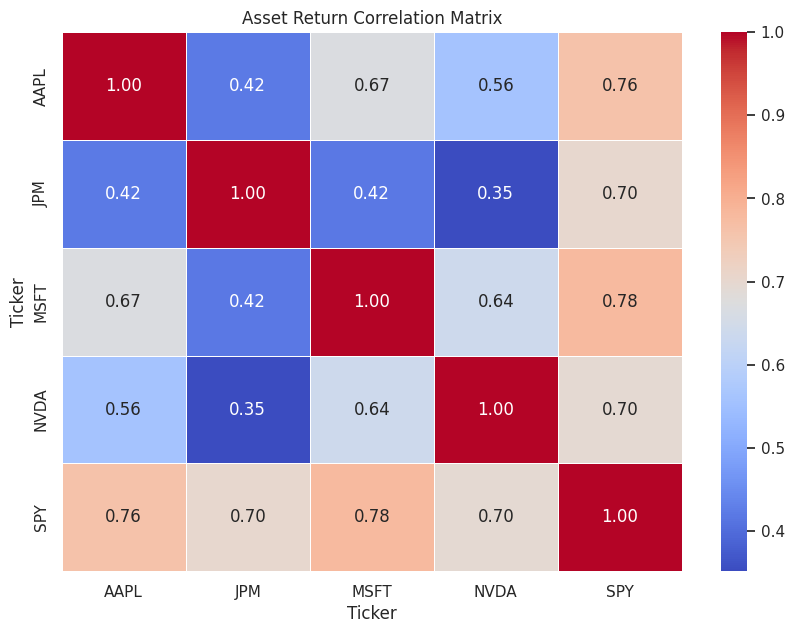

In [82]:
correlation_matrix = daily_returns.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Asset Return Correlation Matrix")
plt.show()

## 6. Historical Drawdown Analysis

This measures how far the portfolio falls from its previous peak. This is useful because investors care not only about returns, but also about how painful the losses can be along the way.

In [83]:
def calculate_drawdown(return_series: pd.Series) -> pd.DataFrame:
    """
    Calculates cumulative return, running peak, and drawdown.
    """
    cumulative_returns = (1 + return_series).cumprod()
    running_peak = cumulative_returns.cummax()
    drawdown = cumulative_returns / running_peak - 1

    return pd.DataFrame({
        "Cumulative Return": cumulative_returns,
        "Running Peak": running_peak,
        "Drawdown": drawdown
    })


drawdown_data = calculate_drawdown(portfolio_daily_returns)
max_drawdown = drawdown_data["Drawdown"].min()

fig = px.area(
    drawdown_data,
    y="Drawdown",
    title=f"Historical Portfolio Drawdown, Max Drawdown: {max_drawdown:.2%}",
    labels={"value": "Drawdown", "Date": "Date"}
)

fig.update_layout(
    template="plotly_white",
    height=500,
    showlegend=False
)

fig.show()

print(f"Maximum historical drawdown: {max_drawdown:.2%}")

Maximum historical drawdown: -35.79%


## 7. Monte Carlo Simulation

The simulation uses historical mean returns, volatility, and correlation to generate thousands of possible future portfolio paths. Each simulated path represents one possible future outcome.

In [84]:
def run_monte_carlo_simulation(
    initial_value: float,
    mean_returns: pd.Series,
    covariance_matrix: pd.DataFrame,
    weights: np.ndarray,
    years: int,
    trading_days_per_year: int,
    num_simulations: int
) -> pd.DataFrame:
    """
    Runs a multi-asset Monte Carlo simulation using correlated daily returns.
    """
    if initial_value <= 0:
        raise ValueError("Initial portfolio value must be positive.")

    if years <= 0:
        raise ValueError("Forecast years must be positive.")

    if num_simulations <= 0:
        raise ValueError("Number of simulations must be positive.")

    forecast_days = years * trading_days_per_year

    try:
        simulated_asset_returns = np.random.multivariate_normal(
            mean=mean_returns.values,
            cov=covariance_matrix.values,
            size=(forecast_days, num_simulations)
        )
    except np.linalg.LinAlgError:
        adjusted_covariance = covariance_matrix + np.eye(len(covariance_matrix)) * 1e-8
        simulated_asset_returns = np.random.multivariate_normal(
            mean=mean_returns.values,
            cov=adjusted_covariance.values,
            size=(forecast_days, num_simulations)
        )

    simulated_portfolio_returns = np.tensordot(
        simulated_asset_returns,
        weights,
        axes=([2], [0])
    )

    simulated_portfolio_values = initial_value * np.cumprod(
        1 + simulated_portfolio_returns,
        axis=0
    )

    simulation_df = pd.DataFrame(
        simulated_portfolio_values,
        columns=[f"Simulation {i + 1}" for i in range(num_simulations)]
    )

    simulation_df.index = range(1, forecast_days + 1)
    simulation_df.index.name = "Trading Day"

    return simulation_df


simulation_results = run_monte_carlo_simulation(
    initial_value=INITIAL_PORTFOLIO_VALUE,
    mean_returns=mean_daily_returns[available_tickers],
    covariance_matrix=cov_daily_returns.loc[available_tickers, available_tickers],
    weights=portfolio_weights,
    years=FORECAST_YEARS,
    trading_days_per_year=TRADING_DAYS_PER_YEAR,
    num_simulations=NUM_SIMULATIONS
)

display(simulation_results.iloc[:5, :5])
print(f"Simulation shape: {simulation_results.shape[0]} trading days x {simulation_results.shape[1]} simulations")

,Simulation 1,Simulation 2,Simulation 3,Simulation 4,Simulation 5
Trading Day,,,,,
1,99262.029553,101015.210260,100707.869442,100699.085427,97730.999848
2,99238.580914,99425.803008,101204.256537,100175.976597,98484.246591
3,97426.179657,99352.681352,101833.650561,102172.908507,99048.829892
4,95278.611103,100558.994830,102454.984158,100807.874185,96151.536169
5,92943.444204,103355.918898,103829.374606,103313.353615,95989.332425


Simulation shape: 1260 trading days x 10000 simulations


## 8. Simulated Portfolio Paths

The chart below shows a sample of simulated paths. Showing every path would be too crowded, so the notebook displays a smaller sample for readability.

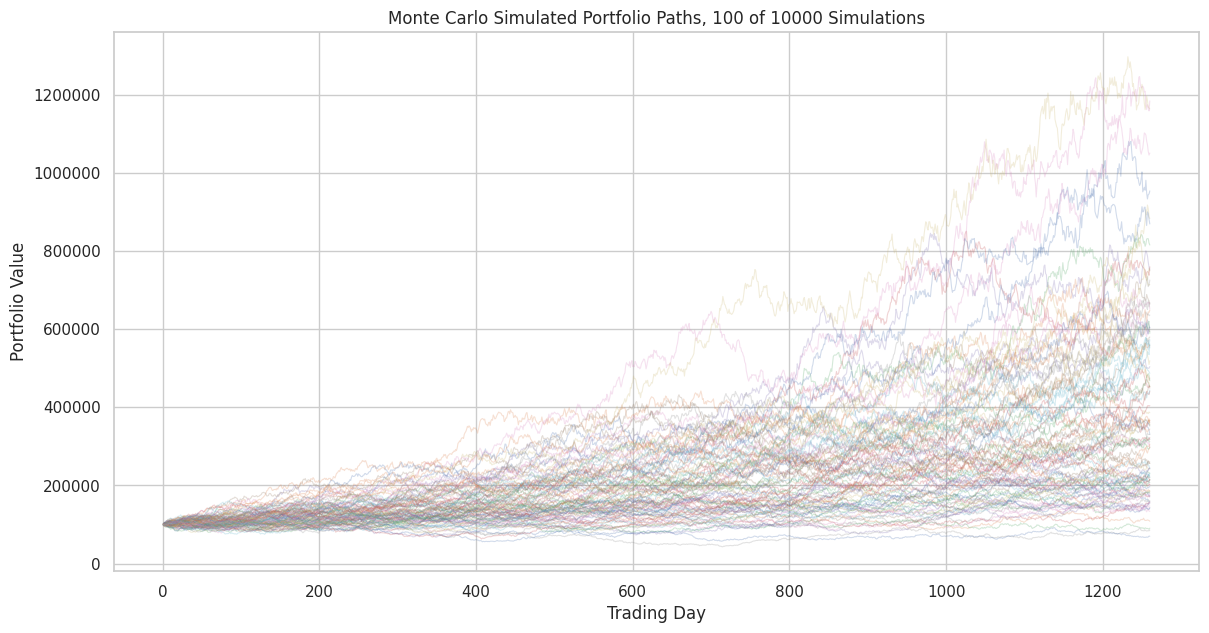

In [85]:
sample_size = min(100, NUM_SIMULATIONS)
sampled_simulations = simulation_results.sample(n=sample_size, axis=1, random_state=RANDOM_SEED)

plt.figure(figsize=(14, 7))

for column in sampled_simulations.columns:
    plt.plot(sampled_simulations.index, sampled_simulations[column], alpha=0.25, linewidth=0.8)

plt.title(f"Monte Carlo Simulated Portfolio Paths, {sample_size} of {NUM_SIMULATIONS} Simulations")
plt.xlabel("Trading Day")
plt.ylabel("Portfolio Value")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

## 9. Forecast Fan Chart

The fan chart shows the range of expected outcomes over time using percentile bands. This is often more useful than looking at individual simulations because it highlights downside, median, and upside scenarios.

In [86]:
percentile_bands = pd.DataFrame({
    "5th Percentile": simulation_results.quantile(0.05, axis=1),
    "25th Percentile": simulation_results.quantile(0.25, axis=1),
    "Median": simulation_results.quantile(0.50, axis=1),
    "75th Percentile": simulation_results.quantile(0.75, axis=1),
    "95th Percentile": simulation_results.quantile(0.95, axis=1)
})

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=percentile_bands.index,
    y=percentile_bands["95th Percentile"],
    mode="lines",
    line=dict(width=0),
    name="95th Percentile",
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=percentile_bands.index,
    y=percentile_bands["5th Percentile"],
    mode="lines",
    fill="tonexty",
    line=dict(width=0),
    name="5th to 95th Percentile Range"
))

fig.add_trace(go.Scatter(
    x=percentile_bands.index,
    y=percentile_bands["75th Percentile"],
    mode="lines",
    line=dict(width=0),
    name="75th Percentile",
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=percentile_bands.index,
    y=percentile_bands["25th Percentile"],
    mode="lines",
    fill="tonexty",
    line=dict(width=0),
    name="25th to 75th Percentile Range"
))

fig.add_trace(go.Scatter(
    x=percentile_bands.index,
    y=percentile_bands["Median"],
    mode="lines",
    name="Median Portfolio Value"
))

fig.update_layout(
    title="Monte Carlo Forecast Fan Chart",
    xaxis_title="Trading Day",
    yaxis_title="Portfolio Value",
    template="plotly_white",
    height=600
)

fig.show()

## 10. Distribution of Ending Portfolio Values

This chart shows the simulated distribution of portfolio values at the end of the forecast period.

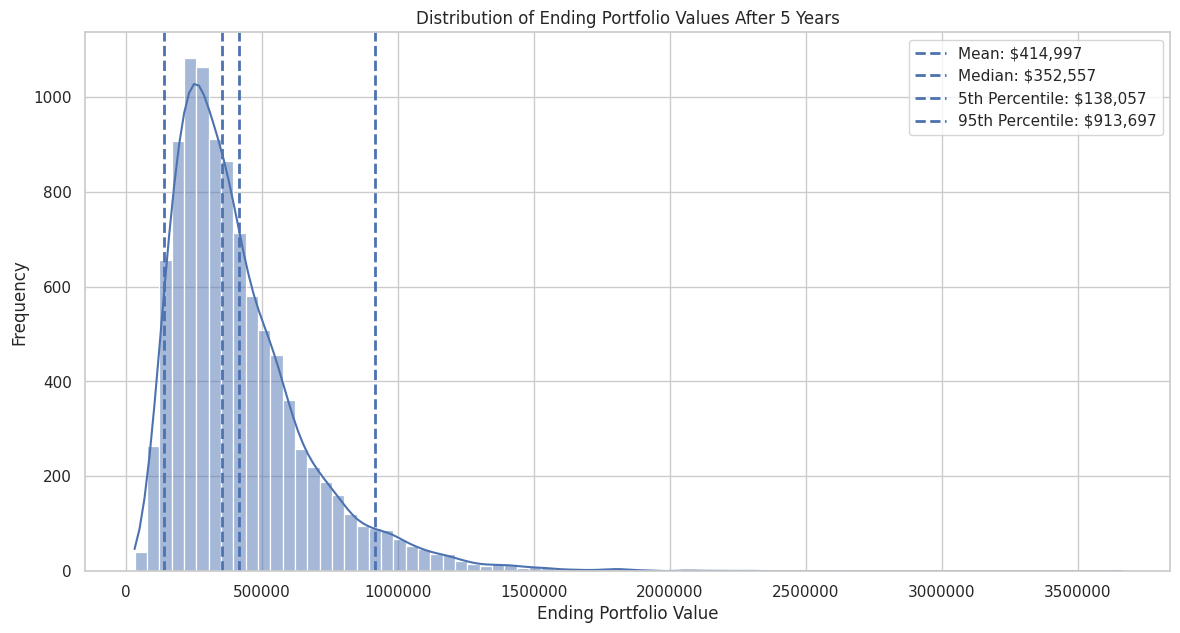

In [87]:
ending_values = simulation_results.iloc[-1]
ending_returns = ending_values / INITIAL_PORTFOLIO_VALUE - 1

mean_ending_value = ending_values.mean()
median_ending_value = ending_values.median()
percentile_5 = ending_values.quantile(0.05)
percentile_95 = ending_values.quantile(0.95)

plt.figure(figsize=(14, 7))
sns.histplot(ending_values, bins=80, kde=True)

plt.axvline(mean_ending_value, linestyle="--", linewidth=2, label=f"Mean: ${mean_ending_value:,.0f}")
plt.axvline(median_ending_value, linestyle="--", linewidth=2, label=f"Median: ${median_ending_value:,.0f}")
plt.axvline(percentile_5, linestyle="--", linewidth=2, label=f"5th Percentile: ${percentile_5:,.0f}")
plt.axvline(percentile_95, linestyle="--", linewidth=2, label=f"95th Percentile: ${percentile_95:,.0f}")

plt.title(f"Distribution of Ending Portfolio Values After {FORECAST_YEARS} Years")
plt.xlabel("Ending Portfolio Value")
plt.ylabel("Frequency")
plt.ticklabel_format(style="plain", axis="x")
plt.legend()
plt.show()

## 11. Risk Metrics

This section calculates key risk metrics, including probability of loss, Value at Risk, expected shortfall, and upside/downside percentile outcomes.

In [88]:
def calculate_simulation_risk_metrics(
    ending_values: pd.Series,
    initial_value: float,
    confidence_level: float
) -> pd.DataFrame:
    """
    Calculates portfolio-level risk metrics from simulated ending values.
    """
    ending_returns = ending_values / initial_value - 1
    alpha = 1 - confidence_level

    value_at_risk_return = ending_returns.quantile(alpha)
    expected_shortfall_return = ending_returns[ending_returns <= value_at_risk_return].mean()

    value_at_risk_dollar = initial_value * abs(value_at_risk_return)
    expected_shortfall_dollar = initial_value * abs(expected_shortfall_return)

    probability_of_loss = (ending_values < initial_value).mean()

    metrics = {
        "Mean Ending Value": ending_values.mean(),
        "Median Ending Value": ending_values.median(),
        "5th Percentile Ending Value": ending_values.quantile(0.05),
        "95th Percentile Ending Value": ending_values.quantile(0.95),
        "Mean Total Return": ending_returns.mean(),
        "Median Total Return": ending_returns.median(),
        "Probability of Loss": probability_of_loss,
        f"{int(confidence_level * 100)}% Value at Risk, Return": value_at_risk_return,
        f"{int(confidence_level * 100)}% Expected Shortfall, Return": expected_shortfall_return,
        f"{int(confidence_level * 100)}% Value at Risk, Dollar Loss": value_at_risk_dollar,
        f"{int(confidence_level * 100)}% Expected Shortfall, Dollar Loss": expected_shortfall_dollar
    }

    return pd.DataFrame(metrics.items(), columns=["Metric", "Value"])


risk_metrics = calculate_simulation_risk_metrics(
    ending_values=ending_values,
    initial_value=INITIAL_PORTFOLIO_VALUE,
    confidence_level=CONFIDENCE_LEVEL
)

percentage_metrics = [
    "Mean Total Return",
    "Median Total Return",
    "Probability of Loss",
    f"{int(CONFIDENCE_LEVEL * 100)}% Value at Risk, Return",
    f"{int(CONFIDENCE_LEVEL * 100)}% Expected Shortfall, Return"
]

formatted_risk_metrics = risk_metrics.copy()


def format_metric(row):
    if row["Metric"] in percentage_metrics:
        return f"{row['Value']:.2%}"
    return f"${row['Value']:,.2f}"


formatted_risk_metrics["Formatted Value"] = formatted_risk_metrics.apply(format_metric, axis=1)

display(formatted_risk_metrics[["Metric", "Formatted Value"]])

,Metric,Formatted Value
0,Mean Ending Value,"$414,996.76"
1,Median Ending Value,"$352,556.83"
2,5th Percentile Ending Value,"$138,057.38"
3,95th Percentile Ending Value,"$913,697.48"
4,Mean Total Return,315.00%
5,Median Total Return,252.56%
6,Probability of Loss,1.36%
7,"95% Value at Risk, Return",38.06%
8,"95% Expected Shortfall, Return",11.03%
9,"95% Value at Risk, Dollar Loss","$38,057.38"


## 12. Scenario Table

This table summarizes downside, base-case, and upside scenarios from the Monte Carlo simulation.

In [89]:
scenario_table = pd.DataFrame({
    "Scenario": [
        "Severe Downside",
        "Downside",
        "Base Case",
        "Upside",
        "Strong Upside"
    ],
    "Percentile": [
        "5th",
        "25th",
        "50th",
        "75th",
        "95th"
    ],
    "Ending Portfolio Value": [
        ending_values.quantile(0.05),
        ending_values.quantile(0.25),
        ending_values.quantile(0.50),
        ending_values.quantile(0.75),
        ending_values.quantile(0.95)
    ]
})

scenario_table["Total Return"] = scenario_table["Ending Portfolio Value"] / INITIAL_PORTFOLIO_VALUE - 1
scenario_table["Annualized Return"] = (scenario_table["Ending Portfolio Value"] / INITIAL_PORTFOLIO_VALUE) ** (1 / FORECAST_YEARS) - 1

display(
    scenario_table.style.format({
        "Ending Portfolio Value": "${:,.2f}",
        "Total Return": "{:.2%}",
        "Annualized Return": "{:.2%}"
    })
)

,Scenario,Percentile,Ending Portfolio Value,Total Return,Annualized Return
0,Severe Downside,5th,"$138,057.38",38.06%,6.66%
1,Downside,25th,"$239,377.53",139.38%,19.07%
2,Base Case,50th,"$352,556.83",252.56%,28.66%
3,Upside,75th,"$522,290.28",422.29%,39.18%
4,Strong Upside,95th,"$913,697.48",813.70%,55.65%


## 13. Sensitivity Analysis

This section compares the base portfolio to alternative portfolio allocations. This is useful because finance professionals usually want to know how results change under different assumptions.

In [90]:
alternative_portfolios = {
    "Base Portfolio": portfolio_weights,
    "Equal Weight": np.repeat(1 / len(available_tickers), len(available_tickers)),
    "Lower Single-Stock Risk": np.array([0.10 if ticker != "SPY" else 0.60 for ticker in available_tickers], dtype=float)
}

alternative_portfolios["Lower Single-Stock Risk"] = (
    alternative_portfolios["Lower Single-Stock Risk"] / alternative_portfolios["Lower Single-Stock Risk"].sum()
)


def calculate_portfolio_stats(
    weights: np.ndarray,
    mean_returns: pd.Series,
    covariance_matrix: pd.DataFrame,
    risk_free_rate: float
) -> Dict[str, float]:
    """
    Calculates annualized return, volatility, and Sharpe ratio for a portfolio.
    """
    annual_return = float(weights.T @ (mean_returns.values * TRADING_DAYS_PER_YEAR))
    annual_volatility = float(np.sqrt(weights.T @ (covariance_matrix.values * TRADING_DAYS_PER_YEAR) @ weights))
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility != 0 else np.nan

    return {
        "Annualized Return": annual_return,
        "Annualized Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio
    }


sensitivity_results = []

for portfolio_name, weights in alternative_portfolios.items():
    stats = calculate_portfolio_stats(
        weights=weights,
        mean_returns=mean_daily_returns[available_tickers],
        covariance_matrix=cov_daily_returns.loc[available_tickers, available_tickers],
        risk_free_rate=risk_free_rate
    )

    sensitivity_results.append({
        "Portfolio": portfolio_name,
        **stats
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

display(sensitivity_df.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}"
}))

,Portfolio,Annualized Return,Annualized Volatility,Sharpe Ratio
0,Base Portfolio,28.48%,25.74%,0.96
1,Equal Weight,28.72%,25.77%,0.96
2,Lower Single-Stock Risk,22.07%,22.11%,0.82


## 14. Export Key Results

This cell creates CSV files with the main outputs. These can be downloaded from Colab and included in a portfolio, GitHub repository, or write-up.

In [91]:
output_files = {}

try:
    asset_summary.to_csv("asset_summary.csv")
    portfolio_summary.to_csv("portfolio_summary.csv", index=False)
    risk_metrics.to_csv("monte_carlo_risk_metrics.csv", index=False)
    scenario_table.to_csv("scenario_table.csv", index=False)
    percentile_bands.to_csv("simulation_percentile_bands.csv")

    output_files = {
        "asset_summary.csv": "Asset-level return and risk metrics",
        "portfolio_summary.csv": "Portfolio return, volatility, and Sharpe ratio",
        "monte_carlo_risk_metrics.csv": "Monte Carlo risk metrics",
        "scenario_table.csv": "Downside, base-case, and upside scenarios",
        "simulation_percentile_bands.csv": "Forecast percentile bands over time"
    }

    print("Files exported successfully:")
    for file_name, description in output_files.items():
        print(f"- {file_name}: {description}")

except Exception as error:
    print(f"Export failed: {error}")

Files exported successfully:
- asset_summary.csv: Asset-level return and risk metrics
- portfolio_summary.csv: Portfolio return, volatility, and Sharpe ratio
- monte_carlo_risk_metrics.csv: Monte Carlo risk metrics
- scenario_table.csv: Downside, base-case, and upside scenarios
- simulation_percentile_bands.csv: Forecast percentile bands over time


## 15. Final Summary

This notebook built a Monte Carlo portfolio risk model using real historical market data. It downloaded asset prices, calculated return and volatility metrics, analyzed correlations and drawdowns, simulated thousands of future portfolio outcomes, and estimated downside risk using Value at Risk, expected shortfall, probability of loss, and scenario analysis.